# 04 - Modelos Alternativos
## APEAJAL - Pronóstico de Precios de Aguacate

**Objetivo:** Explorar una gama diversa de técnicas y enfoques con el fin de identificar el mejor deseméño para el problema de precicción de precios. Encontrar la configuración óptima que maximiza el rendimiento del modelo en la predicción de precios.

**Nombres y matrículas:**

  * José Antonio Gómez Mora | A01374459
  * Alejandro Chávez Campos | A01374974  
  * Laura Patricia Martínez Treviño | A01795967

**Número de Equipo:** 30

In [ ]:
# Montar Google Drive (solo para Colab)
try:
    from google.colab import drive
    drive.mount('/content/drive')
    print('Google Drive montado')
except:
    print('No estás en Colab, usando rutas locales')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive montado


In [ ]:
!pip install scikeras

In [ ]:
import numpy as np
import pandas as pd

from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error

from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, Matern, WhiteKernel
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import ExtraTreesRegressor
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.gaussian_process.kernels import RBF, ExpSineSquared, WhiteKernel
from scikeras.wrappers import KerasRegressor

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import TimeSeriesSplit

from keras.models import Sequential
from keras.layers import LSTM, Dense

import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

import warnings
warnings.filterwarnings("ignore")

## 1. Carga y Exploración de Datos

In [ ]:
DATA_PATH = '/content/drive/MyDrive/MNA/proyecto-integrador/processed2/dataset_completo.csv'
df = pd.read_csv(DATA_PATH, parse_dates=['date'])
df = df.set_index('date').sort_index()
print(f'Shape: {df.shape}')
print(f'Periodo: {df.index.min()} → {df.index.max()}')
df.head()

Shape: (97, 38)
Periodo: 2017-10-01 00:00:00 → 2025-12-01 00:00:00


,precio_promedio,cosecha_tons,embarques_tons,tipo_cambio,temp_min_c,temp_avg_c,temp_max_c,precipitation_mm,importaciones_kg,precio_importacion_usd,...,embarques_tons_log,importaciones_kg_log,precio_promedio_boxcox,tipo_cambio_boxcox,temp_avg_c_boxcox,temp_loca,temp_marcena,temp_normal,month_sin,month_cos
date,,,,,,,,,,,,,,,,,,,,,
2017-10-01,38.055,NaN,NaN,NaN,14.8,22.3,29.8,59.4,65462309.0,2.828279,...,0.0,17.996985,1.248926,NaN,2720.973388,False,False,False,-8.660254e-01,0.500000
2017-11-01,32.500,NaN,NaN,NaN,10.7,20.4,30.0,0.9,69112370.0,2.203476,...,0.0,18.051244,1.238492,NaN,2136.225003,False,False,False,-5.000000e-01,0.866025
2017-12-01,32.500,NaN,NaN,NaN,9.6,18.3,27.0,19.8,82046400.0,2.531162,...,0.0,18.222796,1.238492,NaN,1592.401787,False,False,False,-2.449294e-16,1.000000
2018-01-01,32.500,NaN,NaN,NaN,8.0,17.3,26.5,14.8,93731957.0,2.168603,...,0.0,18.355950,1.238492,NaN,1368.749137,False,False,True,5.000000e-01,0.866025
2018-02-01,32.500,NaN,NaN,NaN,11.0,19.7,28.5,16.2,80709833.0,2.205828,...,0.0,18.206371,1.238492,NaN,1943.405337,False,False,True,8.660254e-01,0.500000


In [ ]:
# Variable objetivo
TARGET = 'precio_proximo_mes'
print(f'\nTarget: {TARGET}')
print(f'Registros con target válido: {df[TARGET].notna().sum()} de {len(df)}')
print(f'\nNulls por columna (top 15):')
print(df.isnull().sum().sort_values(ascending=False).head(15))


Target: precio_proximo_mes
Registros con target válido: 97 de 97

Nulls por columna (top 15):
cosecha_tons                70
embarques_tons              70
ratio_oferta_demanda        70
balance_oferta_demanda      70
precio_importacion_mxn      52
diferencial_precio_mx_us    52
tipo_cambio_boxcox          50
tipo_cambio                 50
temp_min_c                   3
temp_avg_c                   3
temp_precip_interaction      3
precio_lag3                  3
temp_max_c                   3
precipitation_mm             3
temp_avg_c_boxcox            3
dtype: int64


In [ ]:
df["month"] = df.index.month
df["quarter"] = df.index.quarter
df["year"] = df.index.year

## 2. Preparación de Datos

In [ ]:
# Features con buena cobertura (disponibles desde 2015)
FEATURES = [
    # Precio y lags
    'precio_promedio', 'precio_lag1', 'precio_lag2', 'precio_lag3',
    'precio_ma3', 'precio_ma6', 'precio_ma12', 'precio_std3',
    # Temporal
    'month', 'quarter', 'month_sin', 'month_cos',
    # Clima
    'temp_avg_c', 'precipitation_mm',
    # Importaciones
    'importaciones_kg',
    # Tipo de cambio
    'tipo_cambio',
]

def define_dfmodel():
  # Filtrar solo filas con target y features mínimos
  df_model = df[FEATURES + [TARGET]].dropna(subset=[TARGET, 'precio_lag3'])
  print(f'Registros para modelado: {len(df_model)}')
  print(f'Periodo: {df_model.index.min()} → {df_model.index.max()}')
  print(f'\nNulls restantes por columna:')
  print(df_model.isnull().sum()[df_model.isnull().sum() > 0])

  return df_model

In [ ]:
df_model = define_dfmodel()

Registros para modelado: 94
Periodo: 2018-01-01 00:00:00 → 2025-12-01 00:00:00

Nulls restantes por columna:
temp_avg_c           3
precipitation_mm     3
importaciones_kg     2
tipo_cambio         47
dtype: int64


In [ ]:
df["month_sin"] = np.sin(2*np.pi*df.index.month/12)
df["month_cos"] = np.cos(2*np.pi*df.index.month/12)

## 3. Train/Test Split Temporal

In [ ]:
# Imputar NaN restantes con forward fill + media
df_model = df_model.ffill().fillna(df_model.mean())

X = df_model[FEATURES]
y = df_model[TARGET]
print(f'X shape: {X.shape}, y shape: {y.shape}')
print(f'Nulls en X: {X.isnull().sum().sum()}, Nulls en y: {y.isnull().sum()}')

X shape: (94, 16), y shape: (94,)
Nulls en X: 0, Nulls en y: 0


### 4. Metricas

In [ ]:
def compute_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    return mae, rmse, mape

### 5. Definición de modelos

In [ ]:
# SVR
svr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVR())
])

param_grid_svr = {
    "model__kernel":["rbf"],
    "model__C":[0.1,1,10,100],
    "model__epsilon":[0.01,0.1,0.2],
    "model__gamma":["scale","auto"]
}

In [ ]:
# MLP
mlp_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", MLPRegressor(max_iter=5000))
])

param_grid_mlp = {
    "model__hidden_layer_sizes":[(50,), (100,), (50,50)],
    "model__activation":["relu","tanh"],
    "model__alpha":[0.0001,0.001,0.01]
}

In [ ]:

kernel = (
    1.0 * RBF(length_scale=10.0)
    + 1.0 * ExpSineSquared(length_scale=1.0, periodicity=12)
    + WhiteKernel(noise_level=1)
)

# Gaussian Process
gpr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", GaussianProcessRegressor(
        kernel=kernel,
        normalize_y=True
    ))
])

param_grid_gpr = {
    "model__alpha":[1e-10,1e-5,1e-2]
}

In [ ]:
models = {
"SVR": (
  svr_pipeline,
  param_grid_svr
),

"GaussianProcess": (
    gpr_pipeline,
    param_grid_gpr
),

"MLP": (
  mlp_pipeline,
  param_grid_mlp
),

"ExtraTrees": (
    ExtraTreesRegressor(),
    {
        "n_estimators":[100,300],
        "max_depth":[None,5,10],
        "min_samples_split":[2,5]
    }
)
}

### 6. TimeSeriesSplit

In [ ]:
tscv = TimeSeriesSplit(
    n_splits=3,
    test_size=24  # 2 años
)

### 7. Evealuación

In [ ]:
def evaluate_models(models, X, y):
    results = []

    for name, (model, params) in models.items():
        print(f"Entrenando modelo: {name}")

        grid = GridSearchCV(
            model,
            params,
            cv=tscv,
            scoring="neg_mean_absolute_error",
            n_jobs=-1
        )

        grid.fit(X, y)

        best_model = grid.best_estimator_

        mae_list = []
        rmse_list = []
        mape_list = []

        for train_idx, test_idx in tscv.split(X):
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

            best_model.fit(X_train, y_train)

            y_pred = best_model.predict(X_test)

            mae, rmse, mape = compute_metrics(y_test, y_pred)

            mae_list.append(mae)
            rmse_list.append(rmse)
            mape_list.append(mape)

        results.append({
            "Model": name,
            "MAE_mean": np.mean(mae_list),
            "RMSE_mean": np.mean(rmse_list),
            "MAPE_mean": np.mean(mape_list),
            "MAPE_std": np.std(mape_list),
            "Best_params": grid.best_params_

        })

    return pd.DataFrame(results)

### 8. Ejecutar pipeline

In [ ]:
results = evaluate_models(models, X, y)

Entrenando modelo: SVR
Entrenando modelo: GaussianProcess
Entrenando modelo: MLP
Entrenando modelo: ExtraTrees


### 9. Tabla comparativa

In [ ]:
results = results.sort_values("MAPE_mean")

print(results)

             Model   MAE_mean  RMSE_mean  MAPE_mean   MAPE_std  \
3       ExtraTrees   8.548430  11.071656  16.776673   6.284653   
1  GaussianProcess   9.309761  11.486433  17.373433   8.341823   
0              SVR   9.705420  12.457800  17.808685   7.711130   
2              MLP  15.411344  20.276684  36.562513  12.155462   

                                         Best_params  
3  {'max_depth': 10, 'min_samples_split': 5, 'n_e...  
1                             {'model__alpha': 0.01}  
0  {'model__C': 10, 'model__epsilon': 0.2, 'model...  
2  {'model__activation': 'relu', 'model__alpha': ...  


### 10. Gráfica comparativa

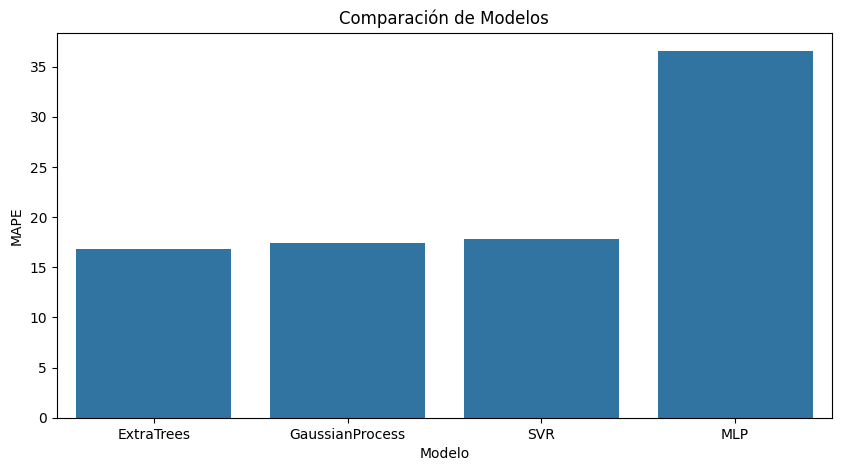

In [ ]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=results,
    x="Model",
    y="MAPE_mean"
)

plt.title("Comparación de Modelos")
plt.ylabel("MAPE")
plt.xlabel("Modelo")

plt.show()

### 11. LSTM

#### 11.1 Secuencias

#### 11.2 LSTM

In [ ]:

# 1. Función para crear ventanas
def create_sequences(X, y, window):

    Xs, ys = [], []

    for i in range(len(X) - window):
        Xs.append(X[i:i+window])
        ys.append(y[i+window])

    return np.array(Xs), np.array(ys)


# 2. Escalar datos
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.values.reshape(-1,1)).flatten()

# 3. Crear secuencias
window = 36

X_seq, y_seq = create_sequences(X_scaled, y_scaled, window)



# 4. Modelo LSTM
def build_lstm(input_shape):

    model = Sequential()

    model.add(LSTM(128, return_sequences=True, input_shape=input_shape))
    model.add(LSTM(64, return_sequences=True))
    model.add(LSTM(32))

    model.add(Dense(16, activation="relu"))
    model.add(Dense(1))

    model.compile(
        optimizer="adam",
        loss="mse"
    )
    return model


# 5. Wrapper para sklearn
lstm_model = KerasRegressor(
    model=build_lstm,
    model__input_shape=(window, X.shape[1]),
    epochs=100,
    batch_size=32,
    verbose=0
)

# 6. Grid de parámetros
param_grid_lstm = {
    "epochs": [100, 200],
    "batch_size": [16, 32]
}

In [ ]:
models["LSTM"] = (
    lstm_model,
    param_grid_lstm
)

#### 11.3 Evaluacuón

In [ ]:

'''mae_list = []
rmse_list = []
mape_list = []

for train_idx, test_idx in tscv.split(X):
    X_train = X.iloc[train_idx].values
    y_train = y.iloc[train_idx].values

    X_test = X.iloc[test_idx].values
    y_test = y.iloc[test_idx].values

    # Escalar train/test (solo usando train para fit)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled  = scaler.transform(X_test)

    # Crear secuencias SOLO con datos del train
    X_train_seq, y_train_seq = create_sequences(X_train, y_train, window)

    # Para el test necesitamos concatenar la última parte del train
    X_combined = np.concatenate([X_train[-window:], X_test])
    y_combined = np.concatenate([y_train[-window:], y_test])
    X_test_seq, y_test_seq = create_sequences(X_combined, y_combined, window)

    model = build_lstm((X_train_seq.shape[1], X_train_seq.shape[2]))

    model.fit(
        X_train_seq,
        y_train_seq,
        epochs=80,
        batch_size=8,
        verbose=0
    )

    y_pred = model.predict(X_test_seq).flatten()

    mae, rmse, mape = compute_metrics(y_test_seq, y_pred)

    mae_list.append(mae)
    rmse_list.append(rmse)
    mape_list.append(mape)'''

'mae_list = []\nrmse_list = []\nmape_list = []\n\nfor train_idx, test_idx in tscv.split(X):\n    X_train = X.iloc[train_idx].values\n    y_train = y.iloc[train_idx].values\n\n    X_test = X.iloc[test_idx].values\n    y_test = y.iloc[test_idx].values\n\n    # Escalar train/test (solo usando train para fit)\n    scaler = StandardScaler()\n    X_train_scaled = scaler.fit_transform(X_train)\n    X_test_scaled  = scaler.transform(X_test)\n\n    # Crear secuencias SOLO con datos del train\n    X_train_seq, y_train_seq = create_sequences(X_train, y_train, window)\n\n    # Para el test necesitamos concatenar la última parte del train\n    X_combined = np.concatenate([X_train[-window:], X_test])\n    y_combined = np.concatenate([y_train[-window:], y_test])\n    X_test_seq, y_test_seq = create_sequences(X_combined, y_combined, window)\n\n    model = build_lstm((X_train_seq.shape[1], X_train_seq.shape[2]))\n\n    model.fit(\n        X_train_seq,\n        y_train_seq,\n        epochs=80,\n        

#### 11.4 Resultado

In [ ]:
'''lstm_results = {
    "Model":"LSTM",
    "MAE_mean":np.mean(mae_list),
    "RMSE_mean":np.mean(rmse_list),
    "MAPE_mean":np.mean(mape_list),
    "MAPE_std":np.std(mape_list)
}'''

'lstm_results = {\n    "Model":"LSTM",\n    "MAE_mean":np.mean(mae_list),\n    "RMSE_mean":np.mean(rmse_list),\n    "MAPE_mean":np.mean(mape_list),\n    "MAPE_std":np.std(mape_list)\n}'

#### 11.5 Integrar

In [ ]:
'''results = pd.concat([results, pd.DataFrame([lstm_results])])'''

'results = pd.concat([results, pd.DataFrame([lstm_results])])'

#### 11.6 Tabla comparativa

In [ ]:
'''results = results.sort_values("MAPE_mean")

print(results)'''

'results = results.sort_values("MAPE_mean")\n\nprint(results)'

#### 11.7 Gráfica comparativa

In [ ]:
'''plt.figure(figsize=(10,5))

sns.barplot(
    data=results,
    x="Model",
    y="MAPE_mean"
)

plt.title("Comparación de Modelos")
plt.ylabel("MAPE")
plt.xlabel("Modelo")

plt.show()'''

'plt.figure(figsize=(10,5))\n\nsns.barplot(\n    data=results,\n    x="Model",\n    y="MAPE_mean"\n)\n\nplt.title("Comparación de Modelos")\nplt.ylabel("MAPE")\nplt.xlabel("Modelo")\n\nplt.show()'

In [ ]:
tscv = TimeSeriesSplit(n_splits=3)

11.8 Visualizar predicciones

In [ ]:

def visualize_forecasting_models(models, X, y, tscv):

    for name, (model, params) in models.items():

        print(f"\nModelo: {name}")

        is_lstm = "LSTM" in name.upper()

        if not is_lstm:

            grid = GridSearchCV(
                model,
                params,
                cv=tscv,
                scoring="neg_mean_absolute_error",
                n_jobs=-1
            )

            grid.fit(X, y)
            best_model = grid.best_estimator_

            preds = np.full(len(y), np.nan)
            test_windows = []

            for train_idx, test_idx in tscv.split(X):

                X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
                y_train = y.iloc[train_idx]

                best_model.fit(X_train, y_train)
                preds[test_idx] = best_model.predict(X_test)

                test_windows.append((test_idx[0], test_idx[-1]))

        else:

            print("Usando secuencias para LSTM")

            X_seq, y_seq = create_sequences(X.values, y.values, window)

            preds = np.full(len(y_seq), np.nan)
            test_windows = []

            for train_idx, test_idx in tscv.split(X_seq):

                X_train, X_test = X_seq[train_idx], X_seq[test_idx]
                y_train = y_seq[train_idx]

                model.fit(X_train, y_train)

                preds[test_idx] = model.predict(X_test).flatten()

                test_windows.append((test_idx[0], test_idx[-1]))

            y = y.iloc[window:]
            preds = preds

        residuals = y.values - preds

        fig = plt.figure(figsize=(20,12))

        # -------- PREDICCION --------
        ax1 = plt.subplot(3,1,1)

        ax1.plot(y.index, y.values, label="Real", linewidth=3)
        ax1.plot(y.index, preds, label="Predicción")

        for start, end in test_windows:
            ax1.axvspan(
                y.index[start],
                y.index[end],
                alpha=0.15
            )

        ax1.set_title(f"Predicción vs Real — {name}")

        ax1.grid(True, linestyle="--", alpha=0.6)

        ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
        ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

        for label in ax1.get_xticklabels():
            label.set_rotation(90)

        ax1.legend()

        # -------- RESIDUALES --------
        ax2 = plt.subplot(3,1,2)

        ax2.plot(y.index, residuals)

        ax2.axhline(0, linestyle="--")

        ax2.set_title("Errores (Residuales)")

        ax2.grid(True, linestyle="--", alpha=0.6)

        ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
        ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

        for label in ax2.get_xticklabels():
            label.set_rotation(90)

        # -------- HISTOGRAMA --------
        ax3 = plt.subplot(3,1,3)

        clean_residuals = residuals[~np.isnan(residuals)]

        ax3.hist(clean_residuals, bins=30)

        ax3.set_title("Distribución de errores")

        ax3.grid(True, linestyle="--", alpha=0.6)

        plt.tight_layout()

        plt.show()


Modelo: SVR


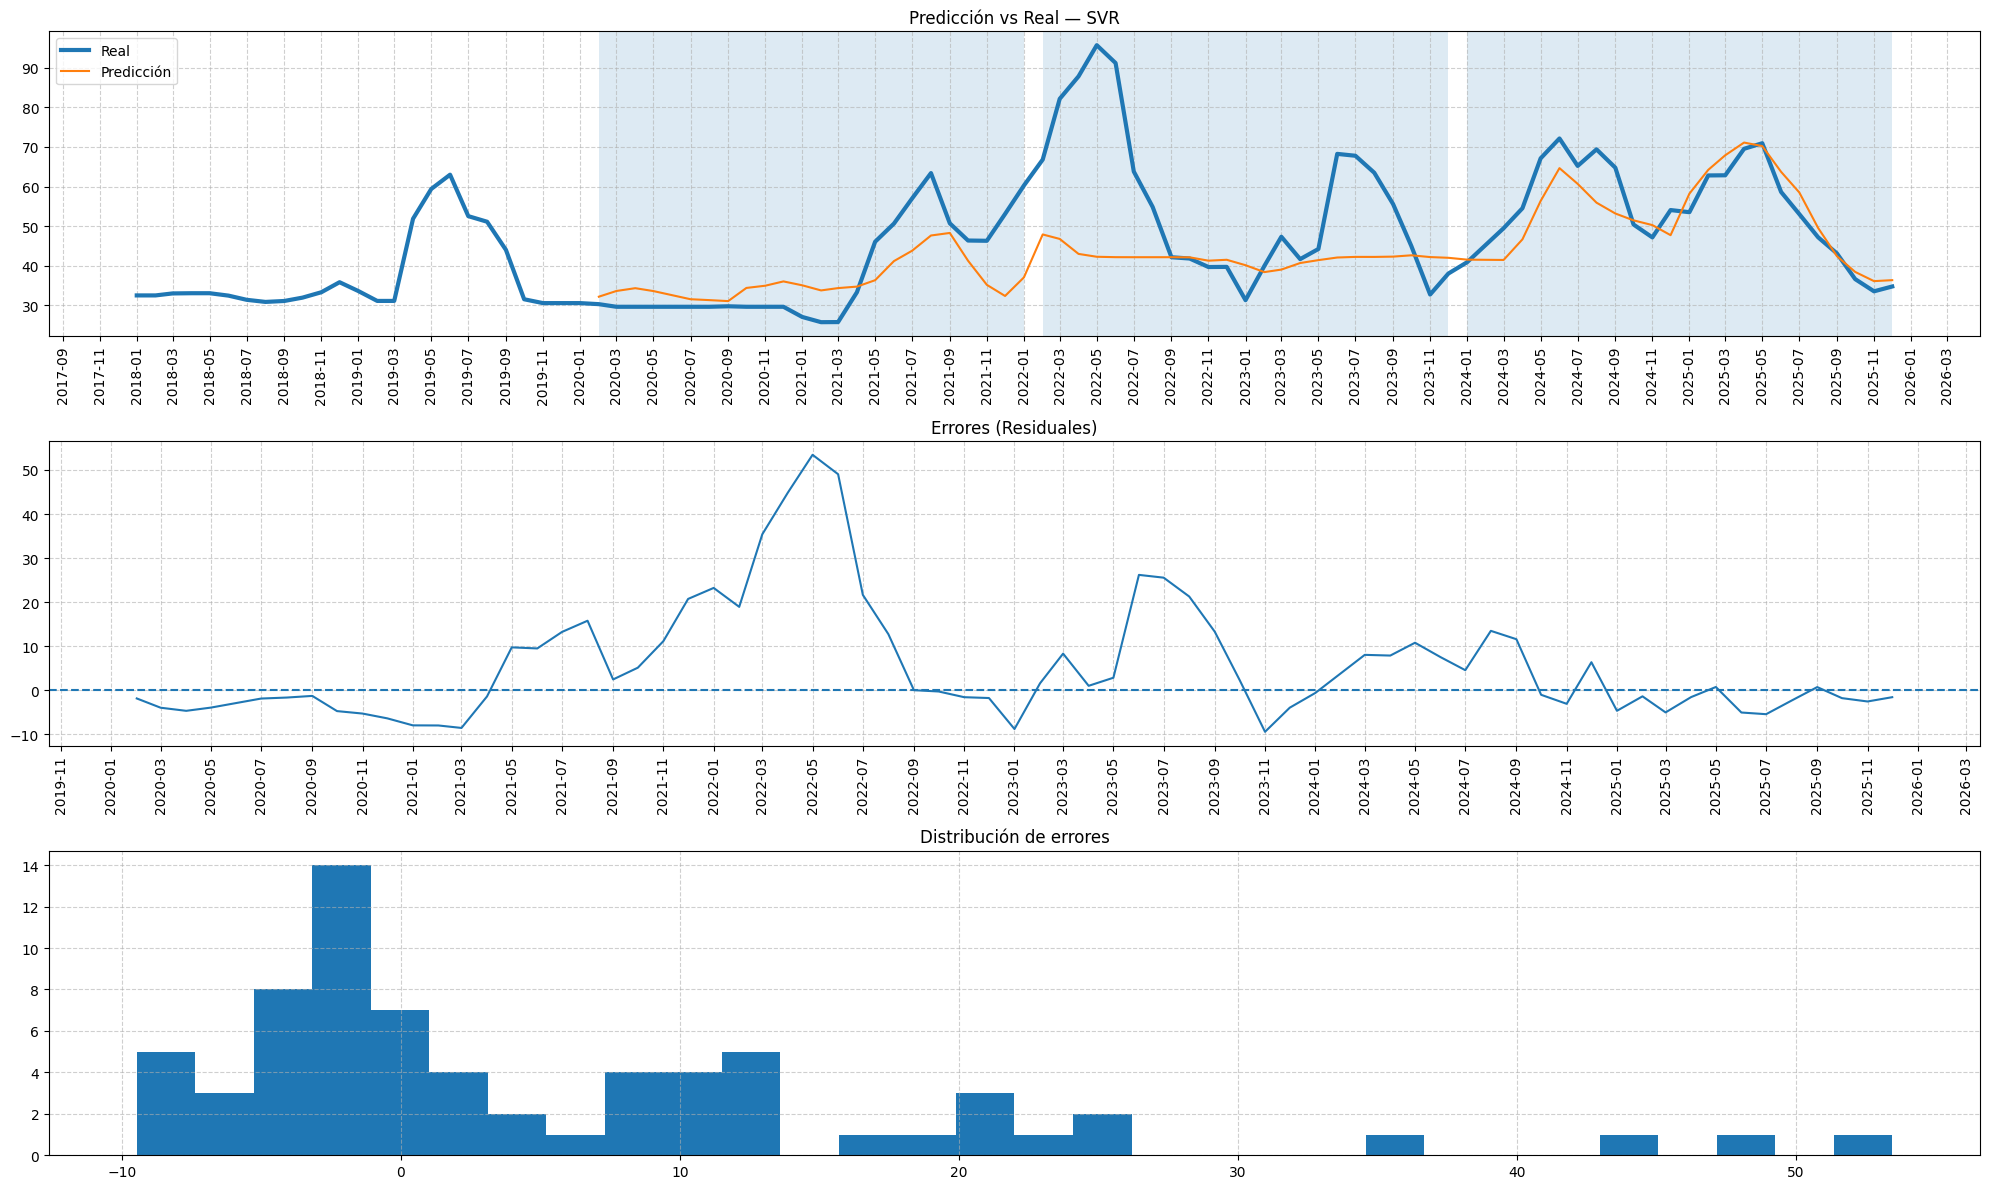


Modelo: GaussianProcess


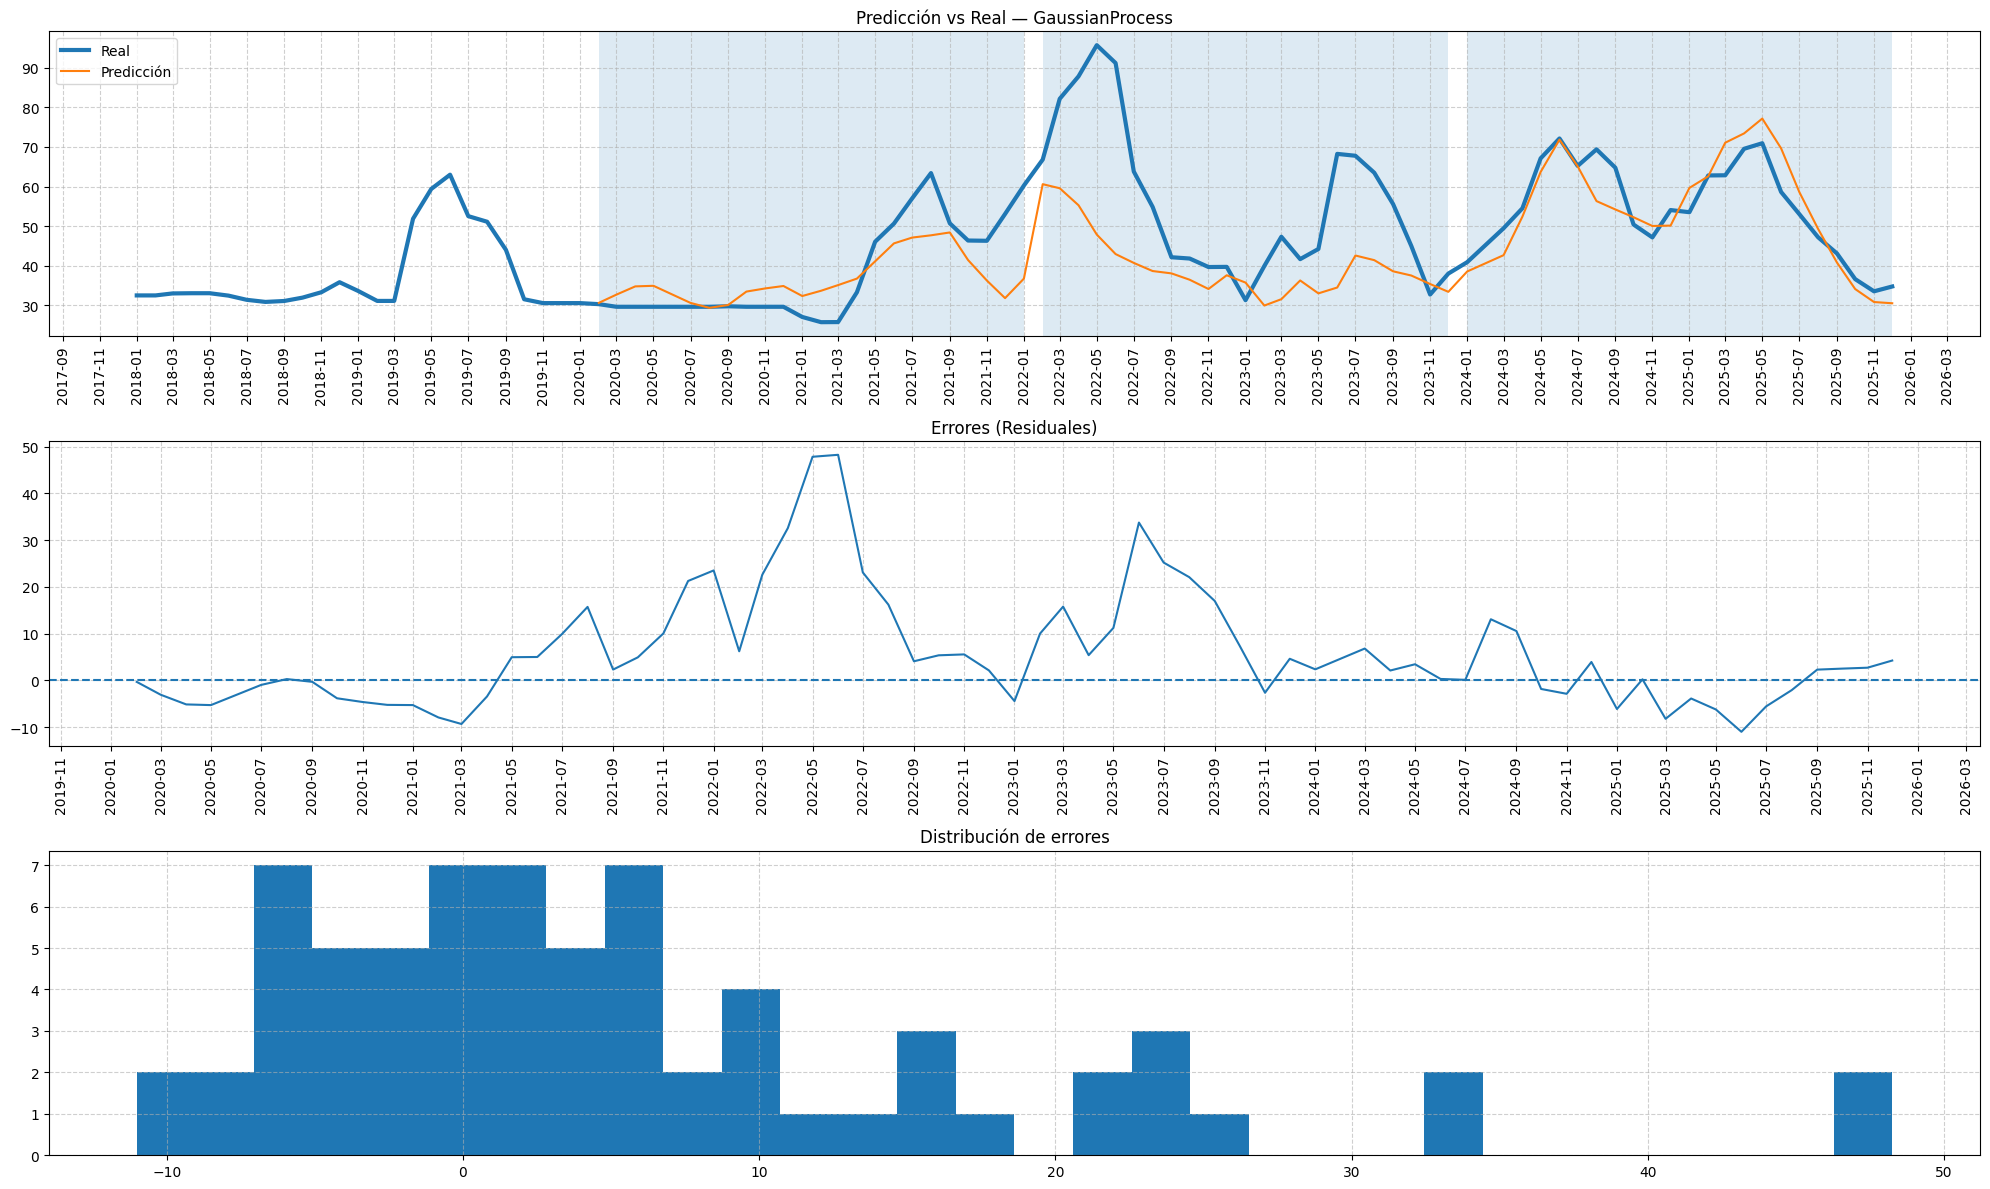


Modelo: MLP


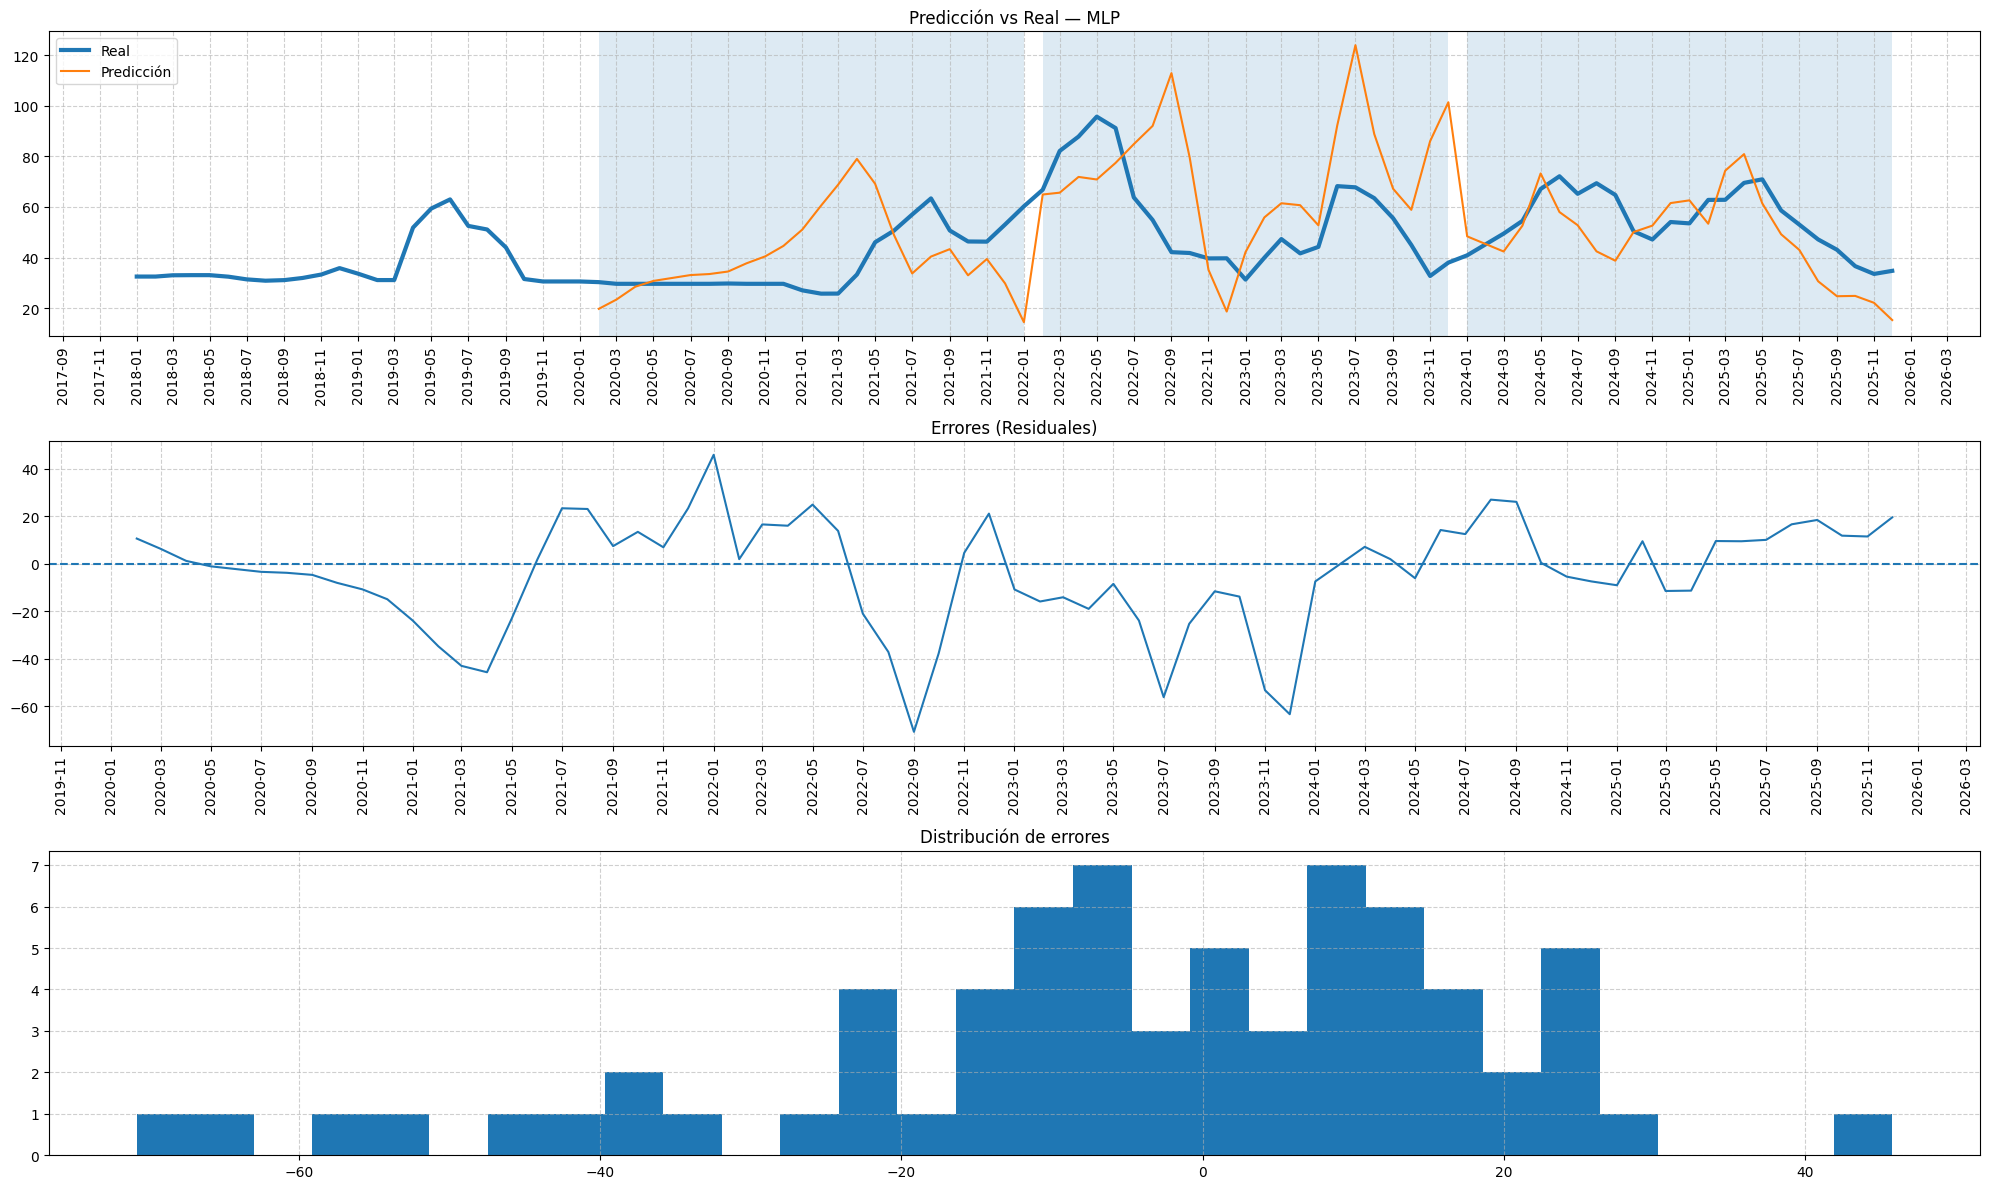


Modelo: ExtraTrees


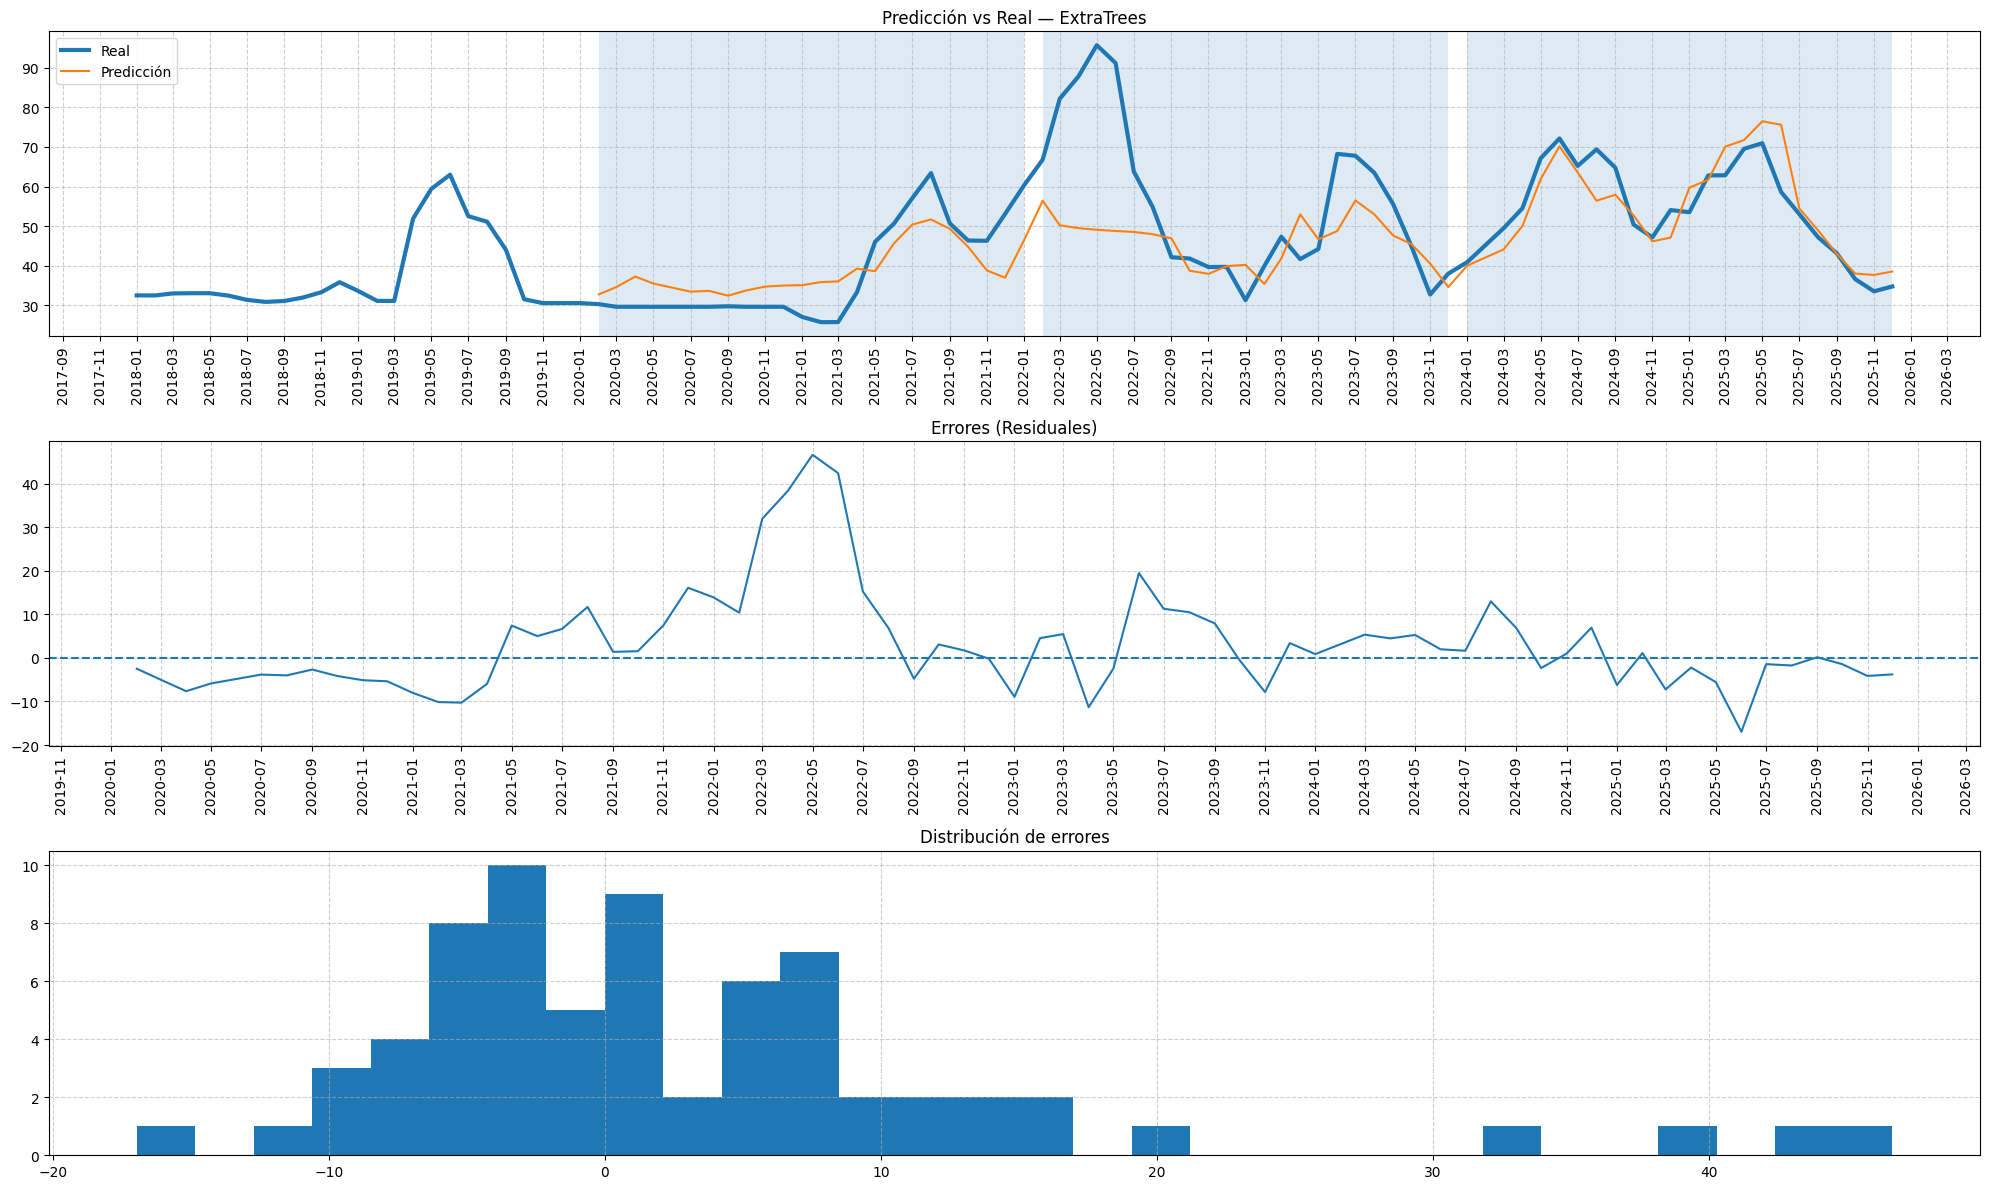


Modelo: LSTM
Usando secuencias para LSTM


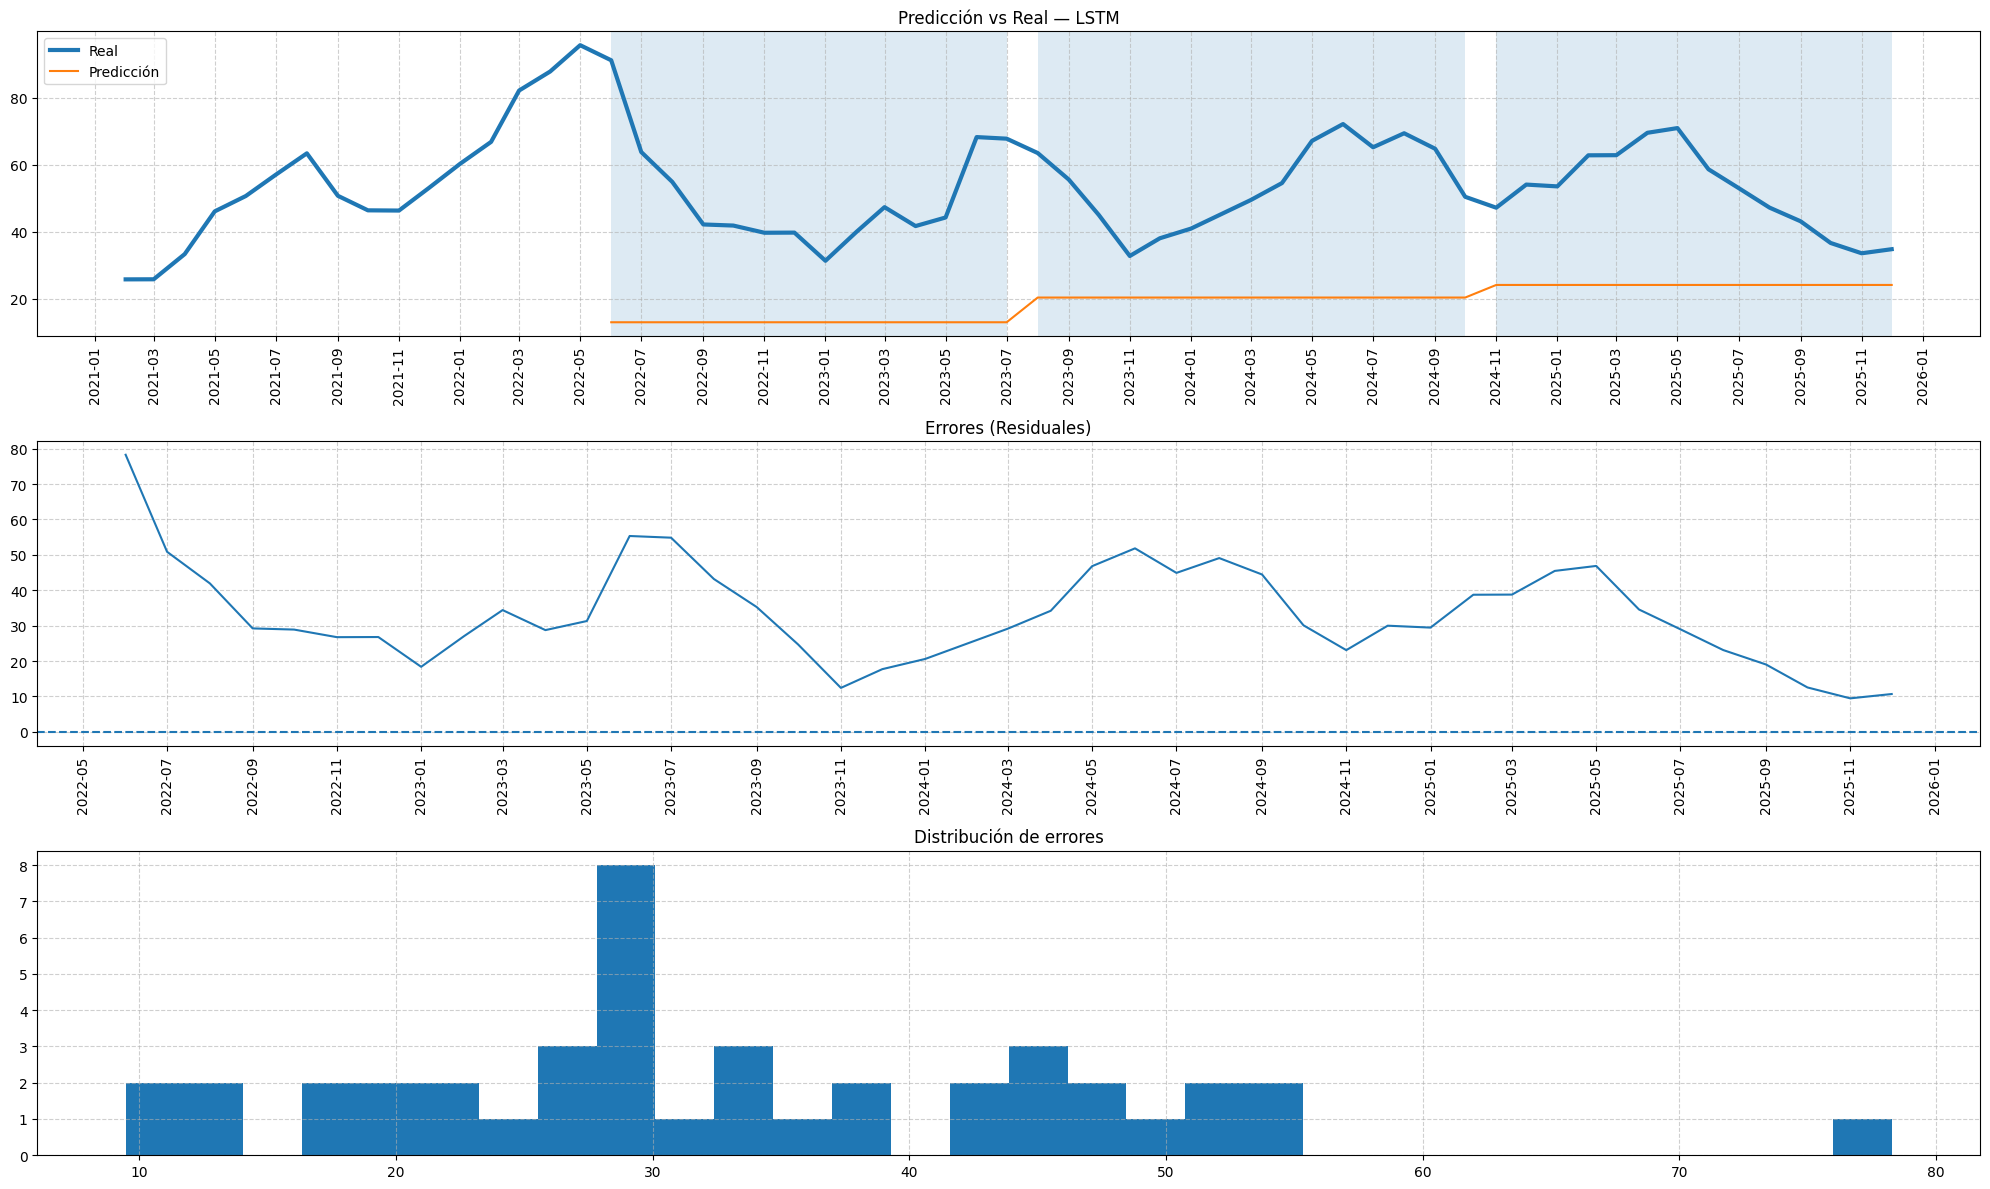

In [ ]:
visualize_forecasting_models(models, X, y, tscv)

In [ ]:
def model_ranking(results_df):

    # ordenar por RMSE
    ranking = results_df.sort_values("RMSE_mean")

    print("\nRanking de modelos (menor error = mejor):\n")
    print(ranking[["Model","MAE_mean","RMSE_mean","MAPE_mean"]])

    # gráfica ranking
    plt.figure(figsize=(12,6))

    plt.barh(
        ranking["Model"],
        ranking["RMSE_mean"]
    )

    plt.xlabel("RMSE")
    plt.title("Ranking de Modelos por RMSE")

    plt.grid(True, linestyle="--", alpha=0.6)

    plt.gca().invert_yaxis()

    plt.show()

    return ranking

In [ ]:
results = evaluate_models(models, X, y)

In [ ]:
ranking = model_ranking(results)

#13. Conclusiones


| Modelo | MAE | RMSE | MAPE | MAPE Std |
| :--- | :--- | :--- | :--- | :--- |
| Ridge (final) | 2.72 | 3.42 | 5.93% | - |
| ExtraTress | 8.62 | 11.14 |16.67% | 5.97 |
| SVR | 9.71 | 12.46 |17.81% | 7.71 |
| MLP | 12.83 | 16.26 |29.57% | 9.97 |
| GaissianProcess | 44.47 | 46.85 |89.90 | 6.91 |
| LSTM | 46.09 | 48.09 |94.10% | 1.61 |


1.   Ridge sigue siendo el mejor modelo
*   Tanto en MAE, RMSE y MAPE, Ridge obtiene errores significativamente menores que cualquier modelo más complejo.
*   Esto refuerza la idea de que para datasets pequeños (~173 observaciones), los modelos lineales regularizados son más confiables.

2.   Modelos basados en árboles y SVR
*   ExtraTrees y SVR tienen errores mayores (MAE ~8–10, MAPE ~17%).
*   Aunque capturan cierta no linealidad, no superan la simplicidad y estabilidad de Ridge en este dataset pequeño.
*   La desviación estándar del MAPE indica que ExtraTrees es algo más consistente que SVR en los folds.

3.   Modelos de deep learning y Gaussian Process
*   LSTM y GaussianProcess presentan errores extremadamente altos (MAPE ~90–94%).
*   Esto es consistente con la literatura: modelos complejos requieren más datos para generalizar.
*   LSTM tiene un MAPE_std bajo (1.61%), lo que indica que fallan siempre de manera consistente, pero aún así no generan predicciones útiles.

*   Los modelos complejos no solo no aportan mejoras, sino que pueden empeorar significativamente la predicción.
*   La regresión lineal regularizada (Ridge) es eficiente, robusta y más interpretable.

Los resultados del análisis comparativo muestran que, en datasets pequeños, los modelos complejos como LSTM o Gaussian Process no superan a modelos lineales regularizados. La regresión Ridge continúa siendo el modelo más efectivo, con un error de test MAPE de 5.93%, significativamente inferior al de los demás modelos.
ExtraTrees y SVR presentan errores moderadamente mayores, indicando que capturan cierta no linealidad pero no logran mejorar la precisión frente a Ridge.
Estos hallazgos refuerzan la idea de que, para predicciones de precios de aguacate en Jalisco con series de tiempo limitadas, los modelos simples y robustos son preferibles, mientras que los modelos de alta complejidad requieren mayor cantidad de datos para generalizar de manera efectiva.